<center><h1><font color='darkblue'>Elektrotehnički fakultet Beograd</font></h1></center>

# Saobraćaj, 2025. godina

Luka Puco 2024/0091

<font color='red'>
Preimenovati svesku u modeli_saobracaj_ime_prezime
</font>

#### __Zadatak 1__: Model sa konstantnom brzinom
Simulirati model protoka saobraćaja sa konstantnom brzinom koji je modelovan parcijalnom diferencijalnom jednačinom:

\begin{equation}
    \frac{\partial\rho(x,t)}{\partial t} + v\frac{\partial\rho(x,t)}{\partial x} = 0
\end{equation}

a) Formirati Python skriptu koja primenom metode konačnih razlika rešava gornju jednačinu za sledeće parametre:
<br>
<ul>
    <li> Brzina automobila $v = 60$ km/h,</li>
    <li> Ukupna dužina posmatranog puta $L = 5$ km,</li>
    <li> Vremenski domen za rešavanje $T = 180$ sekundi,</li>
    <li> Koraci diskretizacije: $\Delta x = 50$ m, $\Delta t = 0.1$ s.</li>
</ul>
Za rešavanje jednačine potrebno je poznavanje početnog uslova:

<ul>
    <li>$\rho(x,0) = 200$ $\text{km}^{-1}$ za $x \leq 0$,</li>
    <li>$\rho(x,0) = 0$ $\text{km}^{-1}$ za $x > 0$,</li>
</ul>

koji može imati smisao semafora koji u trenutku $t = 0$ na poziciji $x = 0$ uključuje zeleno svetlo.

Dodatno potrebno je i poznavanje graničnog uslova $\rho(0,t) = 200$ $\text{km}^{-1}$ za $t > 0$. 

Prikazati 3D grafik i konturni grafik funkcije $\rho(x,t)$. Šta je posledica konstatne brzine vozila?

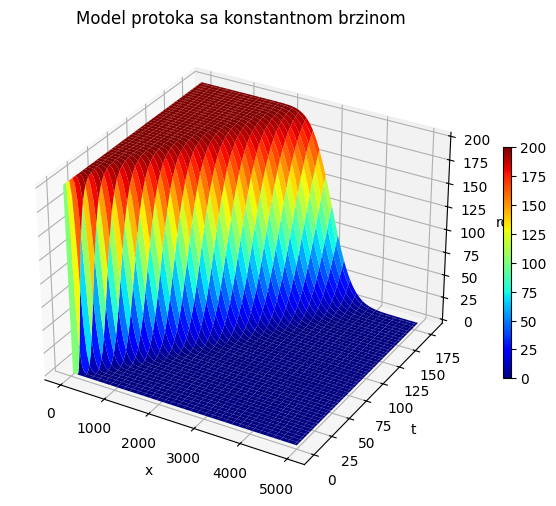

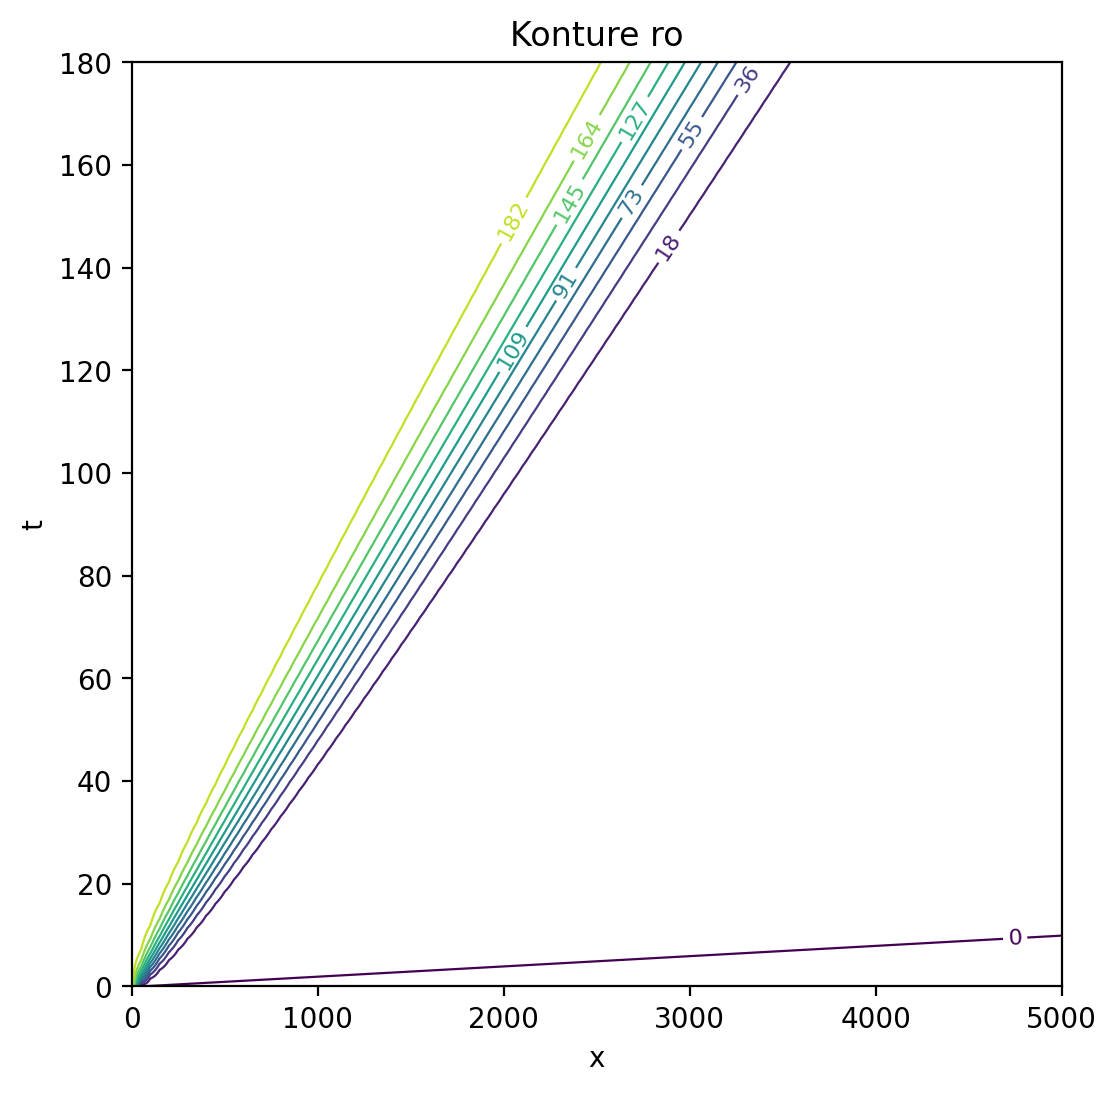

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

v = 60 * 1000 / 3600
L = 5000
T = 180
dx = 50
dt = 0.1

x = np.arange(0, L + dx, dx)
t = np.arange(0, T + dt, dt)

nx = len(x)
nt = len(t)

ro = np.zeros((nt, nx))
ro[0, :] = 0.0
ro[:, 0] = 200.0

c = v * dt / dx
for k in range(nt - 1):
    ro[k + 1, 1:] = ro[k, 1:] - c * (ro[k, 1:] - ro[k, :-1])

X, Y = np.meshgrid(x, t)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, ro, cmap=cm.jet)
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("ro")
ax.set_title("Model protoka sa konstantnom brzinom")
fig.colorbar(surf, shrink=0.5, aspect=30)
plt.show()

levels = np.linspace(0, ro.max(), 12)
plt.figure(figsize=(6,6), dpi=200)
cp = plt.contour(X, Y, ro, levels=levels, linewidths=0.8)
plt.clabel(cp, fmt="%.0f", fontsize=8)
plt.xlabel("x")
plt.ylabel("t")
plt.title("Konture ro")
plt.grid(False)
plt.show()



posledica konstantne brzine je da se gustina samo translira duz puta bez promene oblika.

b) Modelovati isti problem kao iz tačke a) kod koga je promenjen granični uslov, odnosno pretpostavljeno je da postoji semafor koji u trenutku $t = 60$ s uključuje crveno svetlo, a onda u trenutku $t = 120$ s, uključuje zeleno svetlo:
<ul>
    <li> $\rho(0,t) = 200$ $\text{km}^{-1}$ za $0 \leq t < 60$ i $t \geq 120$,</li>
    <li> $\rho(0,t) = 0$ $\text{km}^{-1}$ za $60 \leq t < 120$.</li>
</ul>

Prikazati 3D grafik i konturni grafik funkcije $\rho(x,t)$. Kako je promenjeni granični uslov uticao na rešenje?

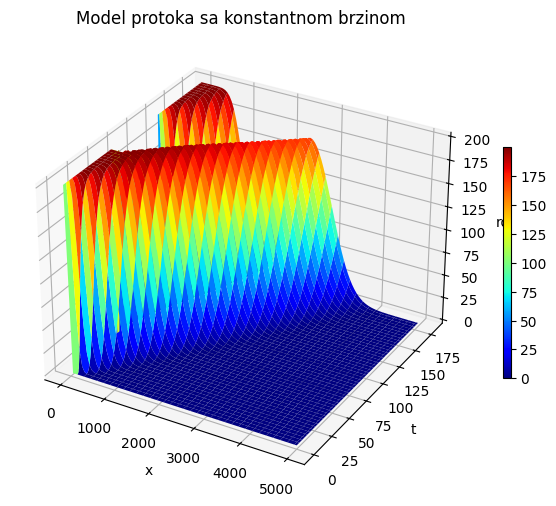

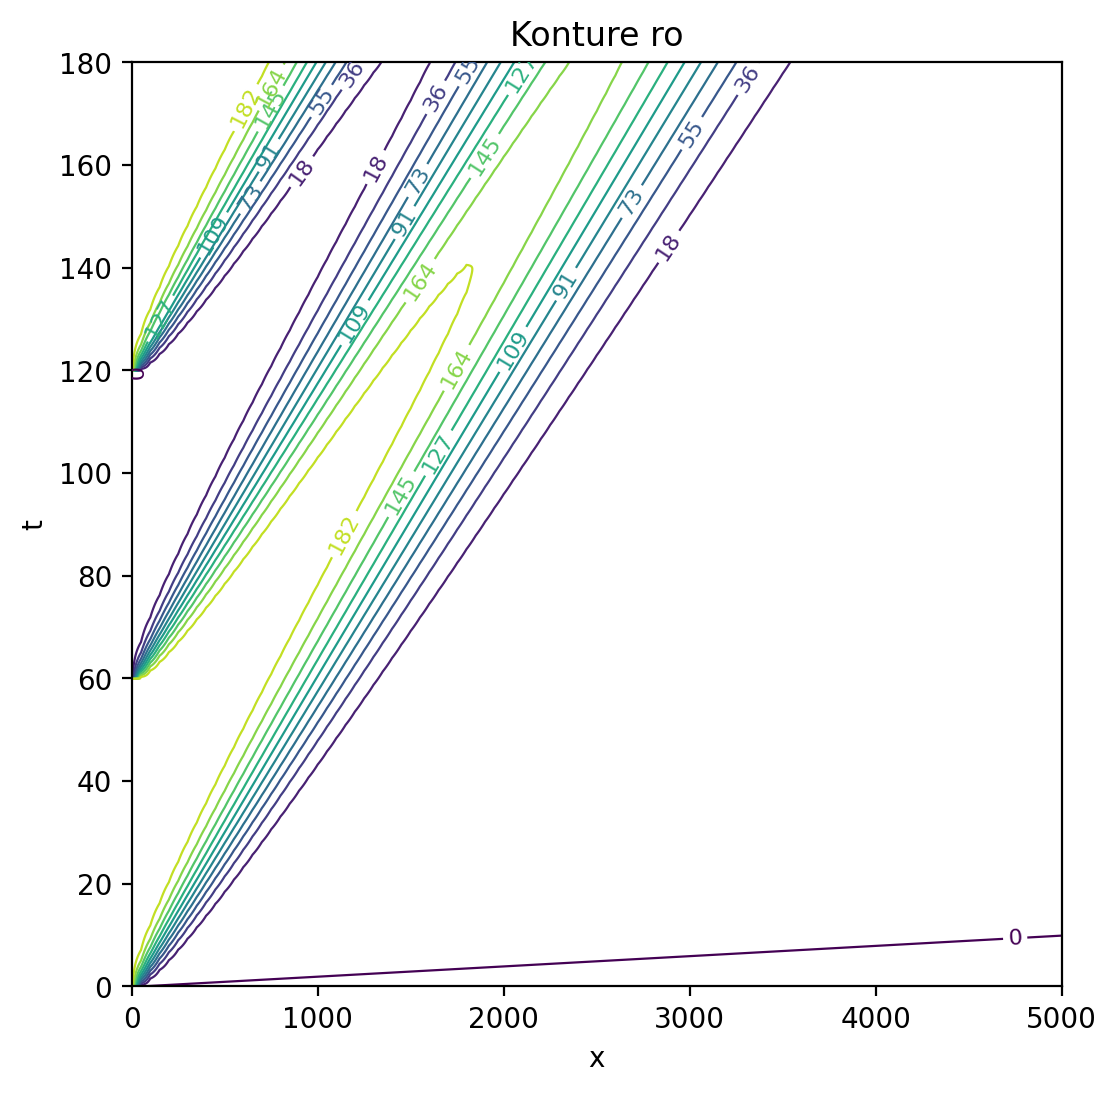

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

v = 60 * 1000 / 3600
L = 5000
T = 180
dx = 50
dt = 0.1

x = np.arange(0, L + dx, dx)
t = np.arange(0, T + dt, dt)
size = t.size

ro = np.zeros((nt, nx))

k60 = int(60 / dt)
k120 = int(120 / dt)
ro[:k60, 0] = 200.0
ro[k60:k120, 0] = 0.0
ro[k120:, 0] = 200.0

c=v*dt/dx
for k in range(size - 1):
    ro[k + 1, 1:] = ro[k, 1:] - c * (ro[k, 1:] - ro[k, :-1])

X, Y = np.meshgrid(x, t)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')#nije htelo da mi radi ax = fig.gca(projection='3d')
surf = ax.plot_surface(X, Y, ro, cmap=cm.jet)
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("ro")
ax.set_title("Model protoka sa konstantnom brzinom")
fig.colorbar(surf, shrink=0.5, aspect=30)
plt.show()

levels = np.linspace(0, ro.max(), 12)
plt.figure(figsize=(6,6), dpi=200)
cp = plt.contour(X, Y, ro, levels=levels, linewidths=0.8)
plt.clabel(cp, fmt="%.0f", fontsize=8)
plt.xlabel("x")
plt.ylabel("t")
plt.title("Konture ro")
plt.grid(False)
plt.show()



zbog promenjenog granicnog uslova opada gustina puta pa se ponovo povecava jer se ponovo pali zeleno svetlo.